In [1]:
import duckdb                     # Motore per query SQL veloci su dataframes
con = duckdb.connect()            # Crea una connessione al database in memoria
import matplotlib.pyplot as plt   # Libreria per creare grafici e visualizzazioni
import pandas as pd               # Libreria per manipolazione e analisi dati
from phm_america_2024.common.path_service_common import find_project_root
# Utility per gestire i percorsi del progetto
from IPython.display import display # Funzione per mostrare output formattati nel notebook

In [2]:

root = find_project_root()

# feature x train
x_train_path = root / "data/raw/train/X_train.csv"
# target y train
y_train_path = root / "data/raw/train/Y_train.csv"

# feature x test
x_test_path = root / "data/raw/test/X_test.csv"

# feature x validation
x_validation_path = root / "data/raw/validation/X_validation.csv"



In [4]:
x_train_pd = pd.read_csv(x_train_path)
print("\nX_train columns:", list(x_train_pd.columns))
print("X_train shape:", x_train_pd.shape)



X_train columns: ['id', 'trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng']
X_train shape: (742625, 8)


In [5]:

y_train_pd = pd.read_csv(y_train_path)
print("\nY_train columns:", list(y_train_pd.columns))
print("Y_train shape:", y_train_pd.shape)



Y_train columns: ['id', 'faulty', 'trq_margin']
Y_train shape: (742625, 3)


In [6]:

x_val_pd = pd.read_csv(x_validation_path)
print("\nx_val columns:", list(x_val_pd.columns))
print("x_val shape:", x_val_pd.shape)



x_val columns: ['id', 'trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng']
x_val shape: (21436, 8)


In [7]:

x_test_pd = pd.read_csv(x_test_path)
print("\nx_test columns:", list(x_test_pd.columns))
print("x_test shape:", x_test_pd.shape)



x_test columns: ['id', 'trq_measured', 'oat', 'mgt', 'pa', 'ias', 'np', 'ng']
x_test shape: (21436, 8)


In [8]:

# 1) Read CSVs (with consistent parameters)

X_train_path = x_train_path
y_train_path = y_train_path


X = pd.read_csv(X_train_path, sep=",", encoding="utf-8", decimal=".", low_memory=False)
Y = pd.read_csv(y_train_path, sep=",", encoding="utf-8", decimal=".", low_memory=False)

# 2) The id column should be int for merging, ensure correct type
X["id"] = X["id"].astype(int)
Y["id"] = Y["id"].astype(int)

# 3) Consistency checks: check for duplicate ids in both X and Y
print("X dup id:", X["id"].duplicated().sum())
print("Y dup id:", Y["id"].duplicated().sum())

# 4) Merge on "id" with inner join and validate one-to-one relationship
df_train = X.merge(Y, on="id", how="inner", validate="one_to_one")

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Merged shape:", df_train.shape)

# 5) Display first 10 rows of the merged DataFrame
display(df_train.head(2))


X dup id: 0
Y dup id: 0
X shape: (742625, 8)
Y shape: (742625, 3)
Merged shape: (742625, 10)


,id,trq_measured,oat,mgt,pa,ias,np,ng,faulty,trq_margin
0,0,54.100,2.00000,544.5000,212.1408,74.56250,89.18000,99.6400,1,-13.717745
1,1,49.625,24.22231,578.4844,1625.6400,30.35596,99.55273,91.3866,0,1.791863


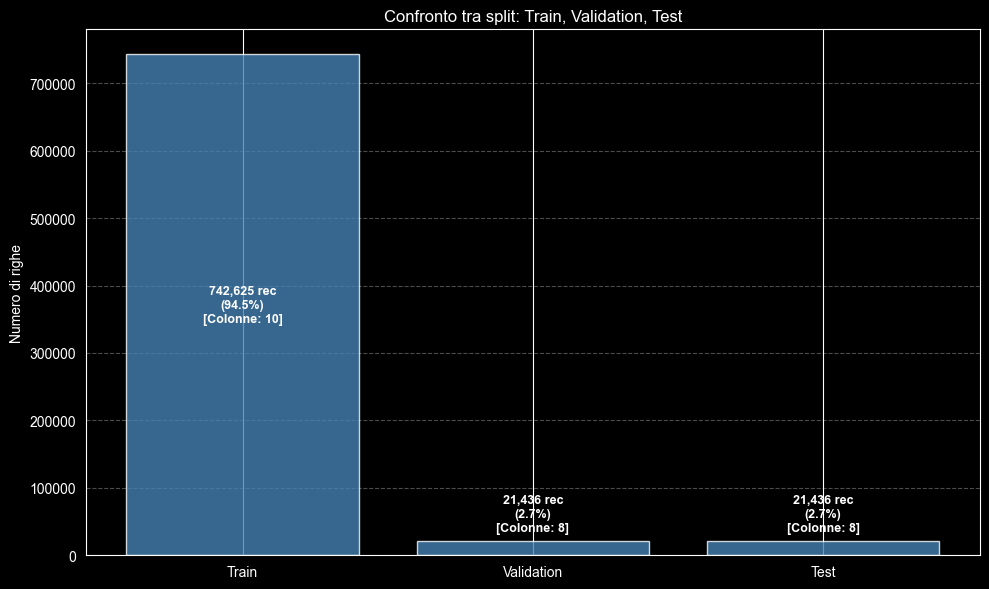

In [23]:

# 1) Prepariamo i dati correttamente
# Creiamo una lista che contiene le informazioni necessarie per ogni barra
# Ogni elemento è: (Nome, DataFrame, Conteggio)
splits_info = [
    ('Train', df_train, len(df_train)),
    ('Validation', x_val_pd, len(x_val_pd)),
    ('Test', x_test_pd, len(x_test_pd))
]

# 2) Configurazione stile
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))

names = [item[0] for item in splits_info]
counts = [item[2] for item in splits_info]
total = sum(counts)

# Disegno le barre
bars = ax.bar(names, counts, color='steelblue', alpha=0.8, edgecolor='white')

# 3) Logica corretta con numero di colonne dinamico
for i, bar in enumerate(bars):
    # Recuperiamo il dataframe corrispondente a questa barra
    current_df = splits_info[i][1]
    col_count = current_df.shape[1] # Ora prende le colonne del df specifico

    height = bar.get_height()
    pct = (height / total) * 100

    label_text = f"{height:,} rec\n({pct:.1f}%)\n[Colonne: {col_count}]"

    # Se la barra è troppo bassa, scriviamo sopra
    if height < (max(counts) * 0.1):
        ax.annotate(label_text,
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom', color='white', fontweight='bold', fontsize=9)
    else:
        # Se è alta, scriviamo dentro
        ax.annotate(label_text,
                    xy=(bar.get_x() + bar.get_width() / 2, height / 2),
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9)

ax.set_title('Confronto tra dataset: Train, Validation, Test', color='white')
ax.set_ylabel('Numero di righe', color='white')
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

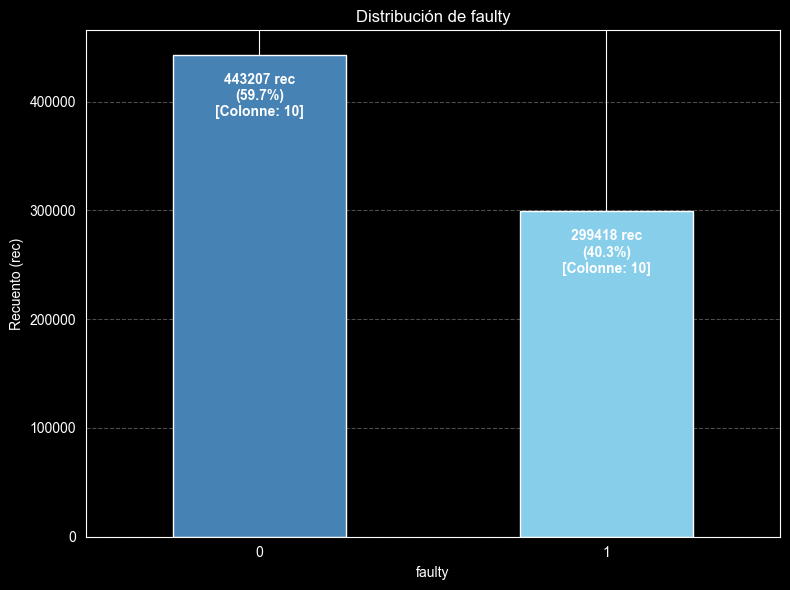

In [18]:

# --- Configuración de Estilo ---
plt.style.use('dark_background')
target_column = 'faulty'
col_id = 'Colonne: 10' # O el identificador que necesites

# --- Cálculo de Datos ---
counts = df_train[target_column].value_counts().sort_index()
total_rec = df_train[target_column].count()
percentages = (counts / total_rec) * 100

# --- Creación del Gráfico ---
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue', 'skyblue']
bars = counts.plot(kind='bar', color=colors, ax=ax)

# --- Añadir Etiquetas ---
for i, bar in enumerate(bars.patches):
    rec_val = int(counts.iloc[i])
    pct_val = percentages.iloc[i]
    label_text = f"{rec_val} rec\n({pct_val:.1f}%)\n[{col_id}]"

    ax.annotate(label_text,
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, -30), # Ajustado para que el texto quede visible dentro de la barra
                textcoords="offset points",
                ha='center', va='center',
                color='white', fontweight='bold', fontsize=10)

# --- Estilo Final ---
ax.set_title(f'Distribución de {target_column}', color='white')
ax.set_ylabel('Recuento (rec)', color='white')
ax.set_xlabel(target_column, color='white')
ax.grid(axis='y', linestyle='--', alpha=0.3, color='white')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [15]:

rename_map = {
    # X (feature)
    "trq_measured": "TORQUE_MEASURED",
    "oat": "OAT",
    "mgt": "MGT",
    "pa": "PA",
    "ias": "IAS",
    "np": "NP",
    "ng": "NG",

    # Y (target)
    "faulty": "FAULTY",
    "trq_margin": "TRQ_MARGIN",
}

df_train_named = df_train.rename(columns=rename_map)

print("Columns (renamed):")
print(df_train_named.columns.tolist())

display(df_train_named.head(4))


Columns (renamed):
['id', 'TORQUE_MEASURED', 'OAT', 'MGT', 'PA', 'IAS', 'NP', 'NG', 'FAULTY', 'TRQ_MARGIN']


,id,TORQUE_MEASURED,OAT,MGT,PA,IAS,NP,NG,FAULTY,TRQ_MARGIN
0,0,54.100,2.00000,544.5000,212.1408,74.56250,89.18000,99.6400,1,-13.717745
1,1,49.625,24.22231,578.4844,1625.6400,30.35596,99.55273,91.3866,0,1.791863
2,2,52.000,7.00000,566.1000,1912.9250,65.62500,100.14000,90.9600,1,-13.944871
3,3,62.400,7.25000,560.1000,277.0632,54.81250,90.64000,100.2800,0,-0.017281


In [12]:
col_desc = {
    "ID": {
        "it": "Indice del campione (ID univoco della riga).",
        "en": "Sample index (unique row ID)."
    },

    # Features (X)
    "TORQUE_MEASURED": {
        "it": "Coppia misurata reale (torque measured).",
        "en": "Measured torque."
    },
    "OAT": {
        "it": "Temperatura dell’aria esterna (OAT).",
        "en": "Outside Air Temperature (OAT)."
    },
    "MGT": {
        "it": "Temperatura media dei gas (MGT).",
        "en": "Mean Gas Temperature (MGT)."
    },
    "PA": {
        "it": "Potenza disponibile (PA).",
        "en": "Power available (PA)."
    },
    "IAS": {
        "it": "Velocità indicata (IAS).",
        "en": "Indicated Airspeed (IAS)."
    },
    "NP": {
        "it": "Potenza netta (NP).",
        "en": "Net power (NP)."
    },
    "NG": {
        "it": "Velocità del compressore (NG).",
        "en": "Compressor speed (NG)."
    },

    # Targets (Y)
    "FAULTY": {
        "it": "Label binaria: 0 = nominale (sano), 1 = guasto.",
        "en": "Binary label: 0 = nominal, 1 = faulty."
    },
    "TRQ_MARGIN": {
        "it": "Torque margin (%) — target di regressione.",
        "en": "Torque margin (%) — regression target."
    },
}

# Create a legend DataFrame for display
legend_rows = []
for c in df_train_named.columns:
    d = col_desc.get(c, {"it": "(descrizione mancante)", "en": "(missing description)"})
    legend_rows.append({"column": c, "IT": d["it"], "EN": d["en"]})
# Display the legend as a DataFrame
legend_df = pd.DataFrame(legend_rows)
display(legend_df)


,column,IT,EN
0,id,(descrizione mancante),(missing description)
1,TORQUE_MEASURED,Coppia misurata reale (torque measured).,Measured torque.
2,OAT,Temperatura dell’aria esterna (OAT).,Outside Air Temperature (OAT).
3,MGT,Temperatura media dei gas (MGT).,Mean Gas Temperature (MGT).
4,PA,Potenza disponibile (PA).,Power available (PA).
5,IAS,Velocità indicata (IAS).,Indicated Airspeed (IAS).
6,NP,Potenza netta (NP).,Net power (NP).
7,NG,Velocità del compressore (NG).,Compressor speed (NG).
8,FAULTY,"Label binaria: 0 = nominale (sano), 1 = guasto.","Binary label: 0 = nominal, 1 = faulty."
9,TRQ_MARGIN,Torque margin (%) — target di regressione.,Torque margin (%) — regression target.


In [13]:
# 1. Crear la tabla de referencia física con tipos de datos adecuados
con.sql("""
CREATE OR REPLACE TABLE referencia_limites (
    campo VARCHAR,
    significado_fisico VARCHAR,
    rango_esperado VARCHAR,
    justificacion_tecnica VARCHAR
);
""")

# 2. Insertar los criterios técnicos con las explicaciones completas de PHM
con.sql("""
INSERT INTO referencia_limites VALUES
(
    'oat',
    'Outside Air Temperature (°C)',
    '-50.0 a 60.0',
    'Límites de temperatura ambiental extrema para la operación de la aeronave. Afecta directamente la densidad del aire de entrada. Temperaturas muy frías aumentan la densidad (mejorando la eficiencia termodinámica), mientras que climas extremadamente cálidos reducen el margen de potencia disponible.'
),
(
    'ias',
    'Indicated Airspeed (Knots)',
    '0.0 a 250.0',
    'Velocidad respecto al aire. Un valor de 0.0 indica estado de hover (vuelo estacionario) o aeronave en pista con motores encendidos. Velocidades altas generan un efecto de presión dinámica (ram recovery) en la admisión, alterando la carga de trabajo del compresor respecto al torque medido.'
),
(
    'pa',
    'Pressure Altitude (Feet)',
    '0.0 a 20000.0',
    'Altitud de presión barométrica de referencia. Define el techo de servicio operativo estándar. A mayor altitud, la presión atmosférica disminuye drásticamente, lo que obliga al motor a operar a mayores revoluciones del núcleo (ng) para intentar comprimir suficiente masa de aire y mantener el torque requerido.'
),
(
    'mgt',
    'Measured Gas Temperature (°C)',
    '200.0 a 1000.0',
    'Temperatura de los gases de escape de la turbina. Valores < 200.0 implican motor apagado o en proceso de arranque. Es el límite térmico crítico del motor: si el compresor está sucio o degradado, la turbina incrementará el flujo de combustible, elevando el mgt de forma anormal para compensar la pérdida de eficiencia.'
),
(
    'ng',
    'Gas Generator Speed (%)',
    '60.0 a 110.0',
    'RPM del núcleo del motor (compresor/turbina de alta). ¡NUNCA DEBE SER 0 EN VUELO! Un valor por debajo del 60% representa un motor en ralentí (idle). Durante operaciones nominales de vuelo, se mantiene en regímenes altos para presurizar el flujo de aire continuo hacia la cámara de combustión. Al escalarse en la Fase 3, puede generar ceros artificiales.'
),
(
    'np',
    'Power Turbine Speed (%)',
    '90.0 a 115.0',
    'RPM de la turbina libre (rotor de potencia). Suele ser altamente estable y cercana al 100% durante el vuelo para garantizar que las palas del rotor principal mantengan la sustentación constante. Variaciones bruscas aquí indican problemas de acoplamiento mecánico o transitorios severos de carga.'
),
(
    'trq_measured',
    'Torque Real Medido (%)',
    '0.0 a 125.0',
    'Fuerza de torsión real instantánea. Medida directamente en el eje de transmisión por torquímetros mecánicos. Valores negativos carecen de sentido físico. Define la potencia real entregada a los rotores; un motor degradado entregará menos torque del esperado para un mismo nivel de consumo de combustible.'
),
(
    'trq_margin',
    'Margen de Torque (%)',
    '-100.0 a 100.0',
    'Variable Objetivo (Target = Teórico - Real). Fuera de los rangos estándar indica una desviación crítica en la salud del activo. Un desvío fuertemente negativo o alejado de cero confirma degradación física (desgaste de álabes, fuga de gases) y gatilla la alerta de mantenimiento preventivo (FAULTY = 1).'
);
""")

print("¡Tabla de referencia física creada con éxito!")

¡Tabla de referencia física creada con éxito!


In [14]:


# 1. Configurar Pandas para mostrar TODO el texto de las celdas sin truncar
pd.set_option('display.max_colwidth', None)

# 2. Asegurar que no oculte columnas si la tabla es ancha
pd.set_option('display.max_columns', None)

# 3. Asegurar que muestre todas las filas de la tabla de referencia
pd.set_option('display.max_rows', None)

# 4. Ejecutar la consulta y guardar el resultado en un DataFrame
df_referencia = con.sql("SELECT * FROM referencia_limites").df()

# 5. Visualizar la tabla completa de manera limpia
display(df_referencia)


,campo,significado_fisico,rango_esperado,justificacion_tecnica
0,oat,Outside Air Temperature (°C),-50.0 a 60.0,"Límites de temperatura ambiental extrema para la operación de la aeronave. Afecta directamente la densidad del aire de entrada. Temperaturas muy frías aumentan la densidad (mejorando la eficiencia termodinámica), mientras que climas extremadamente cálidos reducen el margen de potencia disponible."
1,ias,Indicated Airspeed (Knots),0.0 a 250.0,"Velocidad respecto al aire. Un valor de 0.0 indica estado de hover (vuelo estacionario) o aeronave en pista con motores encendidos. Velocidades altas generan un efecto de presión dinámica (ram recovery) en la admisión, alterando la carga de trabajo del compresor respecto al torque medido."
2,pa,Pressure Altitude (Feet),0.0 a 20000.0,"Altitud de presión barométrica de referencia. Define el techo de servicio operativo estándar. A mayor altitud, la presión atmosférica disminuye drásticamente, lo que obliga al motor a operar a mayores revoluciones del núcleo (ng) para intentar comprimir suficiente masa de aire y mantener el torque requerido."
3,mgt,Measured Gas Temperature (°C),200.0 a 1000.0,"Temperatura de los gases de escape de la turbina. Valores < 200.0 implican motor apagado o en proceso de arranque. Es el límite térmico crítico del motor: si el compresor está sucio o degradado, la turbina incrementará el flujo de combustible, elevando el mgt de forma anormal para compensar la pérdida de eficiencia."
4,ng,Gas Generator Speed (%),60.0 a 110.0,"RPM del núcleo del motor (compresor/turbina de alta). ¡NUNCA DEBE SER 0 EN VUELO! Un valor por debajo del 60% representa un motor en ralentí (idle). Durante operaciones nominales de vuelo, se mantiene en regímenes altos para presurizar el flujo de aire continuo hacia la cámara de combustión. Al escalarse en la Fase 3, puede generar ceros artificiales."
5,np,Power Turbine Speed (%),90.0 a 115.0,RPM de la turbina libre (rotor de potencia). Suele ser altamente estable y cercana al 100% durante el vuelo para garantizar que las palas del rotor principal mantengan la sustentación constante. Variaciones bruscas aquí indican problemas de acoplamiento mecánico o transitorios severos de carga.
6,trq_measured,Torque Real Medido (%),0.0 a 125.0,Fuerza de torsión real instantánea. Medida directamente en el eje de transmisión por torquímetros mecánicos. Valores negativos carecen de sentido físico. Define la potencia real entregada a los rotores; un motor degradado entregará menos torque del esperado para un mismo nivel de consumo de combustible.
7,trq_margin,Margen de Torque (%),-100.0 a 100.0,"Variable Objetivo (Target = Teórico - Real). Fuera de los rangos estándar indica una desviación crítica en la salud del activo. Un desvío fuertemente negativo o alejado de cero confirma degradación física (desgaste de álabes, fuga de gases) y gatilla la alerta de mantenimiento preventivo (FAULTY = 1)."
